In [1]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [10]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
BATCH_SIZE = 8
NUM_EPOCHS = 100
LR = 2e-4
LAMBDA_L1 = 100
IMAGE_SIZE = 256
DATA_ROOT = './urban'

In [11]:
class SAROpticalDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.s1_dir = os.path.join(root_dir, 's1')
        self.s2_dir = os.path.join(root_dir, 's2')
        self.filenames = sorted(os.listdir(self.s1_dir))
        self.transform = transform

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        s1_name = self.filenames[idx]
        s2_name = s1_name.replace("_s1_", "_s2_")

        s1_img = Image.open(os.path.join(self.s1_dir, s1_name)).convert('RGB')
        s2_img = Image.open(os.path.join(self.s2_dir, s2_name)).convert('RGB')
        if self.transform:
            s1_img = self.transform(s1_img)
            s2_img = self.transform(s2_img)
        return s1_img, s2_img

In [12]:
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

from torch.utils.data import random_split, DataLoader

candidate_roots = [
    DATA_ROOT,
    os.path.join(os.getcwd(), 'urban'),
    os.path.join(os.getcwd(), 'data', 'urban'),
]

dataset_root = next(
    (
        p for p in candidate_roots
        if os.path.isdir(os.path.join(p, 's1')) and os.path.isdir(os.path.join(p, 's2'))
    ),
    None
)

if dataset_root is None:
    raise FileNotFoundError(f"Could not find dataset folders 's1' and 's2' in: {candidate_roots}")

dataset = SAROpticalDataset(dataset_root, transform=transform)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

In [13]:
class UNetBlock(nn.Module):
    def __init__(self, in_ch, out_ch, down=True, use_bn=True, dropout=False):
        super().__init__()
        self.use_bn = use_bn
        self.dropout = dropout
        if down:
            self.conv = nn.Conv2d(in_ch, out_ch, 4, 2, 1, bias=False)
        else:
            self.conv = nn.ConvTranspose2d(in_ch, out_ch, 4, 2, 1, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.act = nn.LeakyReLU(0.2) if down else nn.ReLU()
        self.drop = nn.Dropout(0.5)

    def forward(self, x):
        x = self.conv(x)
        if self.use_bn:
            x = self.bn(x)
        if self.dropout:
            x = self.drop(x)
        return self.act(x)

In [14]:
class UNetGenerator(nn.Module):
    def __init__(self, in_ch=3, out_ch=3, features=64):
        super().__init__()
        self.enc1 = UNetBlock(in_ch,      features,     down=True,  use_bn=False)
        self.enc2 = UNetBlock(features,   features*2,   down=True)
        self.enc3 = UNetBlock(features*2, features*4,   down=True)
        self.enc4 = UNetBlock(features*4, features*8,   down=True)
        self.enc5 = UNetBlock(features*8, features*8,   down=True)
        self.enc6 = UNetBlock(features*8, features*8,   down=True)
        self.enc7 = UNetBlock(features*8, features*8,   down=True)
        self.bottleneck = nn.Sequential(
            nn.Conv2d(features*8, features*8, 4, 2, 1), nn.ReLU()
        )
        self.dec1 = UNetBlock(features*8,   features*8, down=False, dropout=True)
        self.dec2 = UNetBlock(features*16,  features*8, down=False, dropout=True)
        self.dec3 = UNetBlock(features*16,  features*8, down=False, dropout=True)
        self.dec4 = UNetBlock(features*16,  features*8, down=False)
        self.dec5 = UNetBlock(features*16,  features*4, down=False)
        self.dec6 = UNetBlock(features*8,   features*2, down=False)
        self.dec7 = UNetBlock(features*4,   features,   down=False)
        self.final = nn.Sequential(
            nn.ConvTranspose2d(features*2, out_ch, 4, 2, 1), nn.Tanh()
        )

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        e5 = self.enc5(e4)
        e6 = self.enc6(e5)
        e7 = self.enc7(e6)
        b  = self.bottleneck(e7)
        d1 = self.dec1(b)
        d2 = self.dec2(torch.cat([d1, e7], 1))
        d3 = self.dec3(torch.cat([d2, e6], 1))
        d4 = self.dec4(torch.cat([d3, e5], 1))
        d5 = self.dec5(torch.cat([d4, e4], 1))
        d6 = self.dec6(torch.cat([d5, e3], 1))
        d7 = self.dec7(torch.cat([d6, e2], 1))
        return self.final(torch.cat([d7, e1], 1))

In [15]:
class PatchGANDiscriminator(nn.Module):
    def __init__(self, in_ch=6, features=64):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_ch,        features,   4, 2, 1),          nn.LeakyReLU(0.2),
            nn.Conv2d(features,     features*2, 4, 2, 1, bias=False), nn.BatchNorm2d(features*2), nn.LeakyReLU(0.2),
            nn.Conv2d(features*2,   features*4, 4, 2, 1, bias=False), nn.BatchNorm2d(features*4), nn.LeakyReLU(0.2),
            nn.Conv2d(features*4,   features*8, 4, 1, 1, bias=False), nn.BatchNorm2d(features*8), nn.LeakyReLU(0.2),
            nn.Conv2d(features*8,   1,          4, 1, 1)
        )

    def forward(self, x, y):
        return self.model(torch.cat([x, y], 1))

In [16]:
G = UNetGenerator().to(DEVICE)
D = PatchGANDiscriminator().to(DEVICE)

criterion_bce = nn.BCEWithLogitsLoss()
criterion_l1  = nn.L1Loss()

opt_G = torch.optim.Adam(G.parameters(), lr=LR, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=LR, betas=(0.5, 0.999))

In [17]:
import time

g_losses, d_losses = [], []
print(f"Dataset size: {len(dataset)}, Batches per epoch: {len(train_loader)}")
print(f"Model device: {next(G.parameters()).device}")

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()
    g_epoch, d_epoch = 0.0, 0.0

    for i, (s1, s2) in enumerate(train_loader):
        s1, s2 = s1.to(DEVICE), s2.to(DEVICE)
        fake_s2 = G(s1)

        D.zero_grad()
        real_pred = D(s1, s2)
        fake_pred = D(s1, fake_s2.detach())
        loss_D = (criterion_bce(real_pred, torch.ones_like(real_pred)) +
                  criterion_bce(fake_pred, torch.zeros_like(fake_pred))) * 0.5
        loss_D.backward()
        opt_D.step()

        G.zero_grad()
        fake_pred = D(s1, fake_s2)
        loss_G = (criterion_bce(fake_pred, torch.ones_like(fake_pred)) +
                  LAMBDA_L1 * criterion_l1(fake_s2, s2))
        loss_G.backward()
        opt_G.step()

        g_epoch += loss_G.item()
        d_epoch += loss_D.item()

        if i == 0:
            print(f"  First batch done in {time.time()-epoch_start:.1f}s | s1 device: {s1.device}")

    g_losses.append(g_epoch / len(train_loader))
    d_losses.append(d_epoch / len(train_loader))
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]  G: {g_losses[-1]:.4f}  D: {d_losses[-1]:.4f}  Time: {time.time()-epoch_start:.1f}s")

Dataset size: 4000, Batches per epoch: 400
Model device: cuda:0
  First batch done in 1.2s | s1 device: cuda:0
Epoch [1/100]  G: 37.0029  D: 0.2864  Time: 215.2s
  First batch done in 0.5s | s1 device: cuda:0
Epoch [2/100]  G: 38.2832  D: 0.3447  Time: 216.9s
  First batch done in 0.5s | s1 device: cuda:0
Epoch [3/100]  G: 38.1626  D: 0.3926  Time: 236.8s
  First batch done in 0.5s | s1 device: cuda:0
Epoch [4/100]  G: 37.8845  D: 0.3943  Time: 271.4s
  First batch done in 0.7s | s1 device: cuda:0
Epoch [5/100]  G: 37.3493  D: 0.4253  Time: 222.1s
  First batch done in 0.6s | s1 device: cuda:0
Epoch [6/100]  G: 36.2292  D: 0.4559  Time: 466.4s
  First batch done in 0.5s | s1 device: cuda:0
Epoch [7/100]  G: 35.0800  D: 0.4522  Time: 158.4s
  First batch done in 0.4s | s1 device: cuda:0
Epoch [8/100]  G: 34.2095  D: 0.4513  Time: 148.6s
  First batch done in 0.4s | s1 device: cuda:0
Epoch [9/100]  G: 33.3509  D: 0.4559  Time: 147.7s
  First batch done in 0.4s | s1 device: cuda:0
Epoch [

KeyboardInterrupt: 

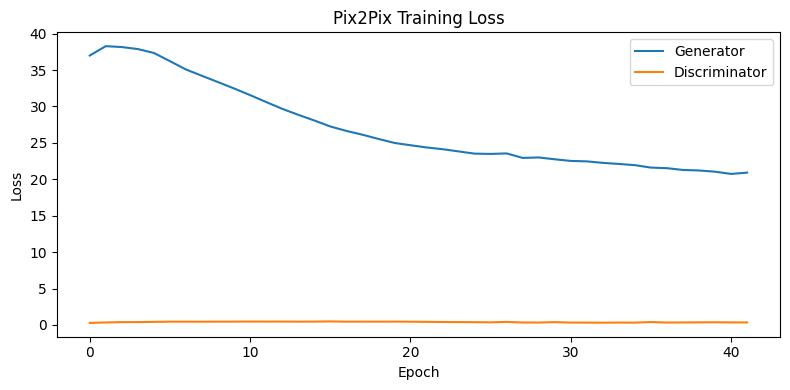

In [18]:
plt.figure(figsize=(8,4))
plt.plot(g_losses, label='Generator')
plt.plot(d_losses, label='Discriminator')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Pix2Pix Training Loss')
plt.legend(); plt.tight_layout(); plt.show()

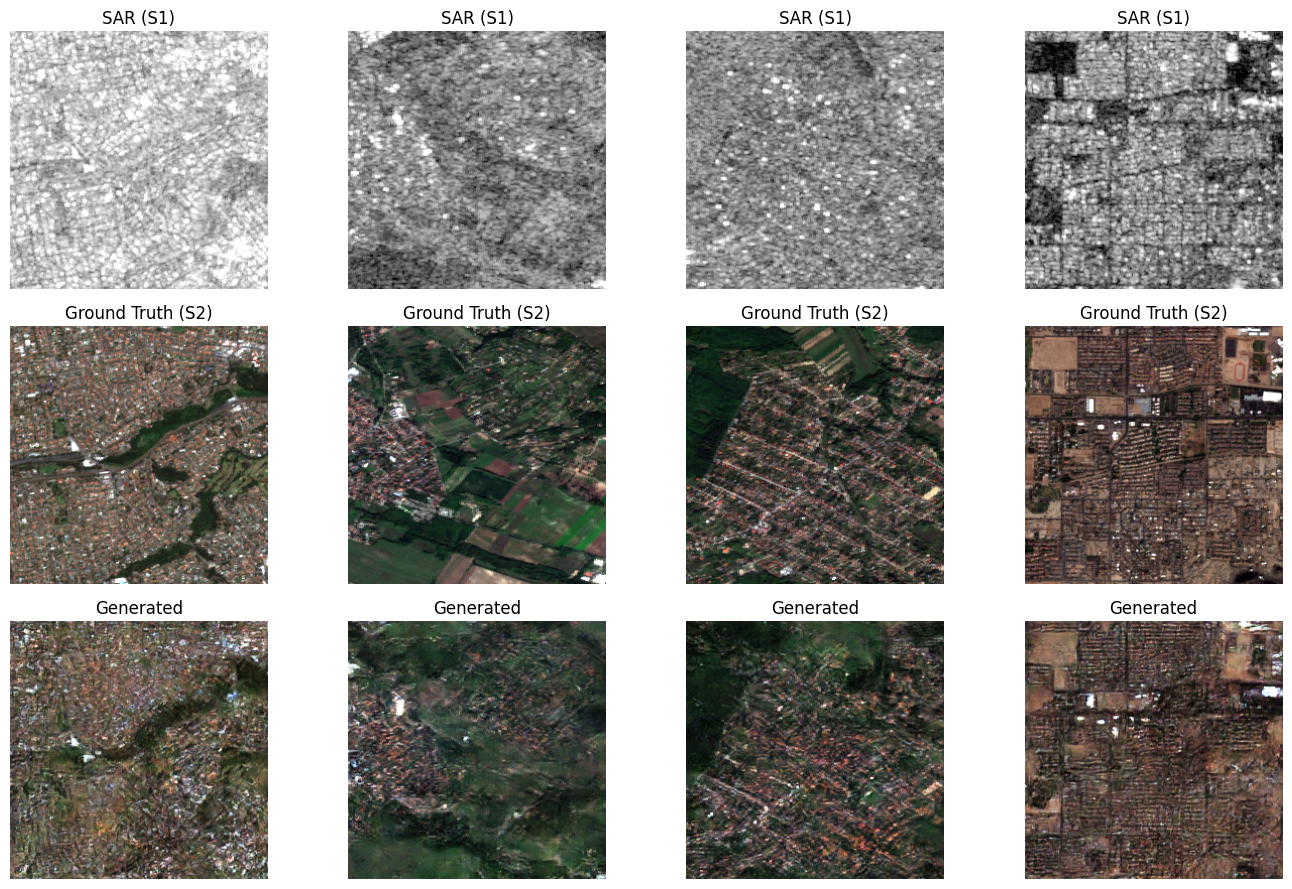

In [21]:
G.eval()

s1_sample, s2_sample = next(iter(test_loader))

s1_sample = s1_sample[:4].to(DEVICE)
s2_sample = s2_sample[:4]

with torch.no_grad():
    fake = G(s1_sample).cpu()

def denorm(t):
    return (t * 0.5 + 0.5).clamp(0,1).permute(1,2,0).numpy()

fig, axes = plt.subplots(3, 4, figsize=(14, 9))

for i in range(4):

    axes[0,i].imshow(denorm(s1_sample[i].cpu()))
    axes[0,i].set_title("SAR (S1)")
    axes[0,i].axis("off")

    axes[1,i].imshow(denorm(s2_sample[i]))
    axes[1,i].set_title("Ground Truth (S2)")
    axes[1,i].axis("off")

    axes[2,i].imshow(denorm(fake[i]))
    axes[2,i].set_title("Generated")
    axes[2,i].axis("off")

plt.tight_layout()
plt.show()

In [20]:
torch.save(G.state_dict(), 'generator_pix2pix.pth')
torch.save(D.state_dict(), 'discriminator_pix2pix.pth')
print('Models saved.')

Models saved.
